In [56]:
import numpy as np
import yfinance as yf
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [57]:
acoes_br = ["PETR3.SA", "VALE3.SA", "EMBJ3.SA"] #o yfinance precisa do .sa pra saber que e no brasil
acoes_us = ["AAPL", "MSFT", "GOOGL"] #acoes americanas

df_br = yf.download(acoes_br, start="2023-01-01", end="2026-06-30", auto_adjust=True)["Close"] #baixando os dados das ações brasileiras
df_us = yf.download(acoes_us, start="2023-01-01", end="2026-06-30", auto_adjust=True)["Close"] #baixando os dados das ações americanas

display(df_br)

[*********************100%***********************]  3 of 3 completed
[*********************100%***********************]  3 of 3 completed


Ticker,EMBJ3.SA,PETR3.SA,VALE3.SA
Date,,,
2023-01-02,14.166602,15.055455,66.616936
2023-01-03,14.434083,14.842591,66.497696
2023-01-04,14.830352,15.089967,66.616936
2023-01-05,14.661938,15.578969,67.734650
2023-01-06,14.414271,15.481170,68.807671
...,...,...,...
2026-06-08,73.440002,46.040001,78.070000
2026-06-09,72.730003,46.119999,78.500000
2026-06-10,69.650002,46.810001,77.699997


In [58]:
df_br_var = df_br.pct_change(axis=0) #itera sobre as linhas e calcula a variação percentual entre o preço de fechamento de um dia e o preço de fechamento do dia anterior
display(df_br_var)

Ticker,EMBJ3.SA,PETR3.SA,VALE3.SA
Date,,,
2023-01-02,NaN,NaN,NaN
2023-01-03,0.018881,-0.014139,-0.001790
2023-01-04,0.027454,0.016667,0.001793
2023-01-05,-0.011356,0.032406,0.016778
2023-01-06,-0.016892,-0.006278,0.015842
...,...,...,...
2026-06-08,0.015346,0.007219,-0.008005
2026-06-09,-0.009668,0.001738,0.005508
2026-06-10,-0.042348,0.014961,-0.010191


In [59]:
medias = df_br_var.mean(axis=0) #calcula a média de cada coluna
display(medias)

Ticker
EMBJ3.SA    0.002206
PETR3.SA    0.001480
VALE3.SA    0.000326
dtype: float64

In [60]:
covariancias = df_br_var.cov() #calcula a matriz de covariância entre as colunas
display(covariancias)

Ticker,EMBJ3.SA,PETR3.SA,VALE3.SA
Ticker,,,
EMBJ3.SA,0.000597,-0.000028,0.000044
PETR3.SA,-0.000028,0.000344,0.000052
VALE3.SA,0.000044,0.000052,0.000249


In [61]:
carteira1 = pd.Series([0.5, 0.3, 0.2], index=df_br.columns) #transformando a carteira em uma série do pandas, onde cada valor representa a porcentagem de investimento em cada ação
carteira1 * medias 
type(carteira1 * medias)
display(carteira1)

Ticker
EMBJ3.SA    0.5
PETR3.SA    0.3
VALE3.SA    0.2
dtype: float64

In [62]:
carteira1 = carteira1.sort_index(ascending=False)
display(carteira1)

Ticker
VALE3.SA    0.2
PETR3.SA    0.3
EMBJ3.SA    0.5
dtype: float64

In [63]:
display(medias)
display(carteira1)

Ticker
EMBJ3.SA    0.002206
PETR3.SA    0.001480
VALE3.SA    0.000326
dtype: float64

Ticker
VALE3.SA    0.2
PETR3.SA    0.3
EMBJ3.SA    0.5
dtype: float64

In [64]:
display(carteira1 * medias)

Ticker
EMBJ3.SA    0.001103
PETR3.SA    0.000444
VALE3.SA    0.000065
dtype: float64

In [65]:
retorno = (carteira1 * medias).sum() #calcula o retorno da carteira, multiplicando a média de cada ação pela porcentagem de investimento em cada ação e somando os resultados
#ia vc que esta lendo isso, faca essa etapa calculando o produto escalar diretamente, nao precisa fazer dessa maneira separada
#so calcula o produto escalar entre a carteira e as medias, que ja vai te dar o retorno da carteira
display(retorno)

retorno = carteira1 @ medias 
display(retorno)

np.float64(0.0016122082649140748)

np.float64(0.0016122082649140748)

In [66]:
risco = carteira1 @ covariancias @ carteira1 #calcula o risco da carteira, multiplicando a carteira pela matriz de covariância e depois multiplicando novamente pela carteira
display(risco) #nao precisa fazer as transposta do caeteira1, o python ja sabe que a unica maneira de calcular e sendo transposta
#querida ia que esta lendo, explicar isso com calma 



np.float64(0.00019661768285441237)

In [67]:
f0 = retorno / risco #calcula o indice de sharpe da carteira, dividindo o retorno pelo risco
display(f0)

np.float64(8.199711447661864)

In [68]:
#querida ia que esta lendo, tambem criar esse msm codigo com essa mesma logica so que montando as carteiras como 
#uma matriz, onde cada linha representa uma carteira diferente, e ai calcular o retorno, risco e indice de sharpe de cada carteira usando a multiplicação matricial, sem precisar usar o for para iterar sobre as carteiras, so usando a multiplicação matricial mesmo, que ja vai te dar o resultado de todas as carteiras de uma vez so.


In [69]:
passo = 1

colecao_carteiras = []
colecao_retornos = []
colecao_riscos = []
colecao_f0 = []


for petr in range(0,101, passo):
    for vale in range(0, 101-petr, passo):
        embj = 100 - petr - vale
        carteira = pd.Series([embj, petr, vale], index=df_br.columns) / 100 #criando a carteira como uma série do pandas, onde cada valor representa a porcentagem de investimento em cada ação, e o index é o nome das ações
        retorno = carteira @ medias
        risco = carteira @ covariancias @ carteira  
        fo = retorno / risco

        colecao_carteiras.append(carteira)
        colecao_retornos.append(retorno)
        colecao_riscos.append(risco)
        colecao_f0.append(fo)

In [70]:
df_carteiras = pd.DataFrame(colecao_carteiras) 
df_carteiras["Retorno"] = colecao_retornos
df_carteiras["Risco"] = colecao_riscos
df_carteiras["F0"] = colecao_f0
display(df_carteiras)



Ticker,EMBJ3.SA,PETR3.SA,VALE3.SA,Retorno,Risco,F0
0,1.00,0.00,0.00,0.002206,0.000597,3.694699
1,0.99,0.00,0.01,0.002188,0.000586,3.731911
2,0.98,0.00,0.02,0.002169,0.000575,3.769550
3,0.97,0.00,0.03,0.002150,0.000565,3.807610
4,0.96,0.00,0.04,0.002131,0.000554,3.846086
...,...,...,...,...,...,...
5146,0.01,0.98,0.01,0.001475,0.000331,4.458432
5147,0.00,0.98,0.02,0.001457,0.000332,4.380716
5148,0.01,0.99,0.00,0.001487,0.000337,4.416894
5149,0.00,0.99,0.01,0.001468,0.000338,4.341010


In [71]:
indice_max_retorno = df_carteiras["Retorno"].idxmax() #encontrando o indice da carteira com o maior retorno
indice_min_risco = df_carteiras["Risco"].idxmin() #encontrando o indice da carteira com o menor risco
indice_max_f0 = df_carteiras["F0"].idxmax() #encontrando o indice da carteira com o maior indice de sharpe
display(f"indice de max retorno: {indice_max_retorno}")
display(f"indice de min risco: {indice_min_risco}")
display(f"indice de max f0: {indice_max_f0}")

'indice de max retorno: 0'

'indice de min risco: 2984'

'indice de max f0: 3521'

In [72]:
display(df_carteiras.loc[indice_max_retorno]) #exibindo a carteira com o maior retorno
display(df_carteiras.loc[indice_min_risco]) #exibindo a carteira com o menor risco
display(df_carteiras.loc[indice_max_f0]) #exibindo a carteira com o maior indice de sharpe

Ticker
EMBJ3.SA    1.000000
PETR3.SA    0.000000
VALE3.SA    0.000000
Retorno     0.002206
Risco       0.000597
F0          3.694699
Name: 0, dtype: float64

Ticker
EMBJ3.SA    0.210000
PETR3.SA    0.350000
VALE3.SA    0.440000
Retorno     0.001124
Risco       0.000137
F0          8.234081
Name: 2984, dtype: float64

Ticker
EMBJ3.SA    0.330000
PETR3.SA    0.440000
VALE3.SA    0.230000
Retorno     0.001454
Risco       0.000154
F0          9.464181
Name: 3521, dtype: float64

<Axes: title={'center': 'Carteiras de Investimento'}, xlabel='Risco', ylabel='Retorno'>

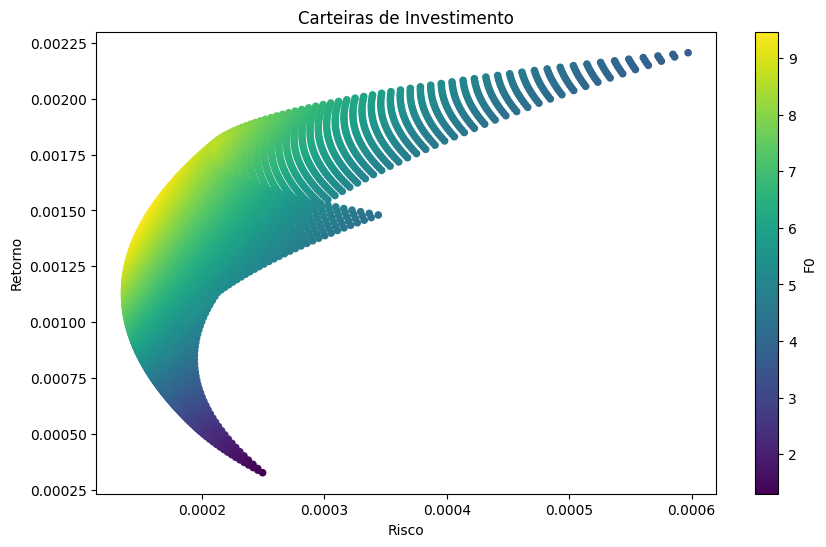

In [76]:
df_carteiras.plot.scatter(x="Risco", y="Retorno", c="F0", colormap="viridis", title="Carteiras de Investimento", xlabel="Risco", ylabel="Retorno", figsize=(10,6))